# Analyzation of the Wiund Speed Prediction for Zeynep

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.ticker as mticker
import dataclasses
import pandas as pd

from pkg.data_preparation.run_graphcast_forecast import _get_model_checkpoint
from graphcast import data_utils

In [21]:
def plot_wind_speed_comparison(
    predictions_path: str,
    input_path: str,
    lon_min: float = 7.625,
    lon_max: float = 10.625,
    lat_min: float = 53.125,
    lat_max: float = 55.125,
    grid_spacing: float = 0.25,
    model_name: str = "graphcast_operational",
    time_index: int = 0,
    time_label: str = None
):
    """
    Plot observed vs. predicted wind speed over a specified region.

    Parameters:
        predictions_path (str): Path to the prediction NetCDF file.
        input_path (str): Path to the input NetCDF file.
        lon_min, lon_max, lat_min, lat_max (float): Bounding box coordinates.
        grid_spacing (float): Spacing for lat/lon gridlines.
        model_name (str): Name of the model (used to extract task config).
        time_index (int): Index to use for time slice.
        time_label (str, optional): Label for the time shown in the plot titles.
                                    If not provided, defaults to "Unknown UTC".
    """
    # Load input dataset and extract targets
    with xr.open_dataset(predictions_path) as ds:
        predictions = ds.load()

    with xr.open_dataset(input_path) as ds:
        example_batch = ds.load()

    ckpt, _, _ = _get_model_checkpoint(model_name)
    task_config = ckpt.task_config

    _, eval_targets, _ = data_utils.extract_inputs_targets_forcings(
        example_batch, target_lead_times=slice("6h", "6h"),
        **dataclasses.asdict(task_config)
    )

    # Compute wind speed
    u_true = eval_targets["10m_u_component_of_wind"].isel(time=time_index).squeeze("batch")
    v_true = eval_targets["10m_v_component_of_wind"].isel(time=time_index).squeeze("batch")
    wind_true = np.sqrt(u_true**2 + v_true**2)

    u_pred = predictions["10m_u_component_of_wind"].isel(time=time_index).squeeze("batch")
    v_pred = predictions["10m_v_component_of_wind"].isel(time=time_index).squeeze("batch")
    wind_pred = np.sqrt(u_pred**2 + v_pred**2)

    # Region slice
    region = dict(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))
    true_region = wind_true.sel(**region)
    pred_region = wind_pred.sel(**region)

    # Fixed color scale from 11 to 21 m/s
    vmin = 11
    vmax = 21

    # Use provided label or fallback
    time_label = time_label or "Unknown UTC"
    titles = [f"Observed Wind Speed at {time_label}", f"Predicted Wind Speed at {time_label}"]

    # Plotting
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})

    for ax, data, title in zip(axs, [true_region, pred_region], titles):
        im = data.plot.pcolormesh(
            ax=ax, cmap="viridis", add_colorbar=False, transform=ccrs.PlateCarree(),
            vmin=vmin, vmax=vmax
        )
        ax.set_title(title)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}
        gl.xlocator = mticker.MultipleLocator(grid_spacing)
        gl.ylocator = mticker.MultipleLocator(grid_spacing)

        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.3)

        # Hamburg shape
        hamburg_shape = gpd.read_file("data/gadm41_DEU_2.json")
        hamburg_shape = hamburg_shape[hamburg_shape["NAME_1"] == "Hamburg"]
        hamburg_shape.boundary.plot(ax=ax, edgecolor="black", linewidth=1.2, transform=ccrs.PlateCarree())

        # Add city markers
        city_coords = {
            "Hamburg": (10.0, 53.55),
            "Kiel": (10.1228, 54.3233),
            "Flensburg": (9.4469, 54.7939),
            "Cuxhaven": (8.6942, 53.8647),
            "Büsum": (8.8581, 54.1291),
            "Bremen": (8.8012, 53.0793),
            "Bremerhaven": (8.5809, 53.5396),
        }

        for city, (lon, lat) in city_coords.items():
            ax.plot(lon, lat, 'wo', markersize=5, transform=ccrs.PlateCarree())
            ax.text(lon + 0.05, lat, city, color='white', fontsize=9, transform=ccrs.PlateCarree())


    # Shared colorbar
    cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.025, pad=0.02)
    cbar.set_label("10m Wind Speed (m/s)")

    plt.subplots_adjust(wspace=0.15, right=0.87)
    plt.show()


### Operational

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_21021/4029458296.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  with xr.open_dataset(predictions_path) as ds:


📦 Using checkpoint: graphcast/params/GraphCast_operational - ERA5-HRES 1979-2021 - resolution 0.25 - pressure levels 13 - mesh 2to6 - precipitation output only.npz


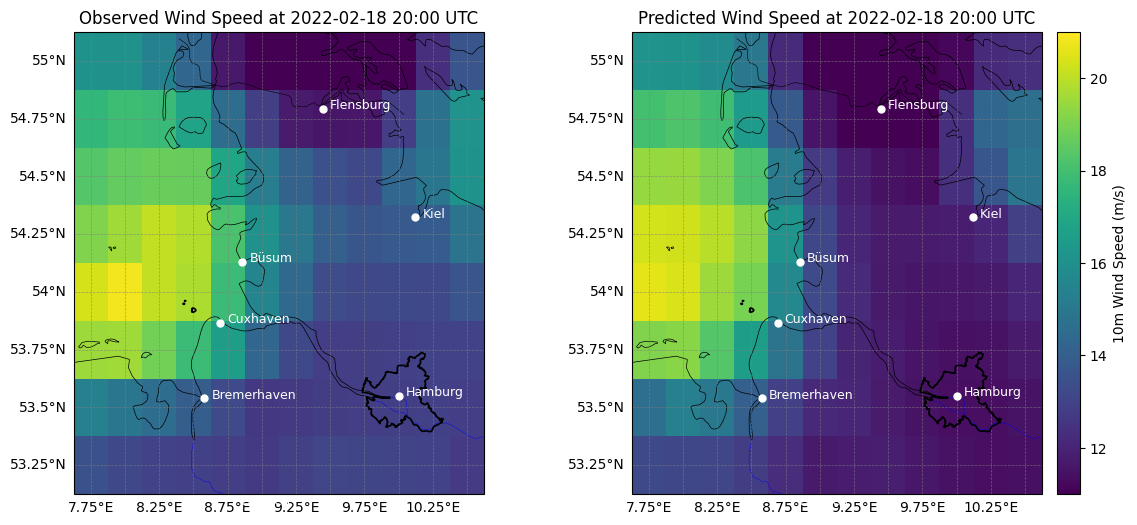

In [22]:
plot_wind_speed_comparison(
    predictions_path="data/predictions/zeynep_20_prediction_graphcast_operational.nc",
    input_path="data/input_data/zeynep_20_graphcast_operational/graphcast_ready_input_zeynep_20_graphcast_operational.nc",
    time_label="2022-02-18 20:00 UTC"
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_21021/4029458296.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  with xr.open_dataset(predictions_path) as ds:


📦 Using checkpoint: graphcast/params/GraphCast_operational - ERA5-HRES 1979-2021 - resolution 0.25 - pressure levels 13 - mesh 2to6 - precipitation output only.npz


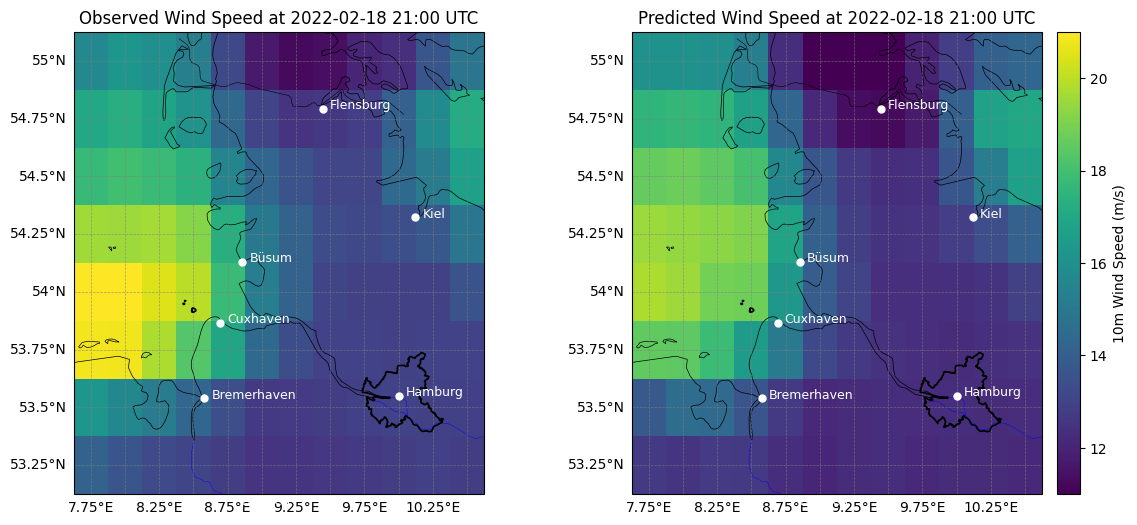

In [23]:
plot_wind_speed_comparison(
    predictions_path="data/predictions/zeynep_21_prediction_graphcast_operational.nc",
    input_path="data/input_data/zeynep_21_graphcast_operational/graphcast_ready_input_zeynep_21_graphcast_operational.nc",
    time_label="2022-02-18 21:00 UTC"
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_21021/4029458296.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  with xr.open_dataset(predictions_path) as ds:


📦 Using checkpoint: graphcast/params/GraphCast_operational - ERA5-HRES 1979-2021 - resolution 0.25 - pressure levels 13 - mesh 2to6 - precipitation output only.npz


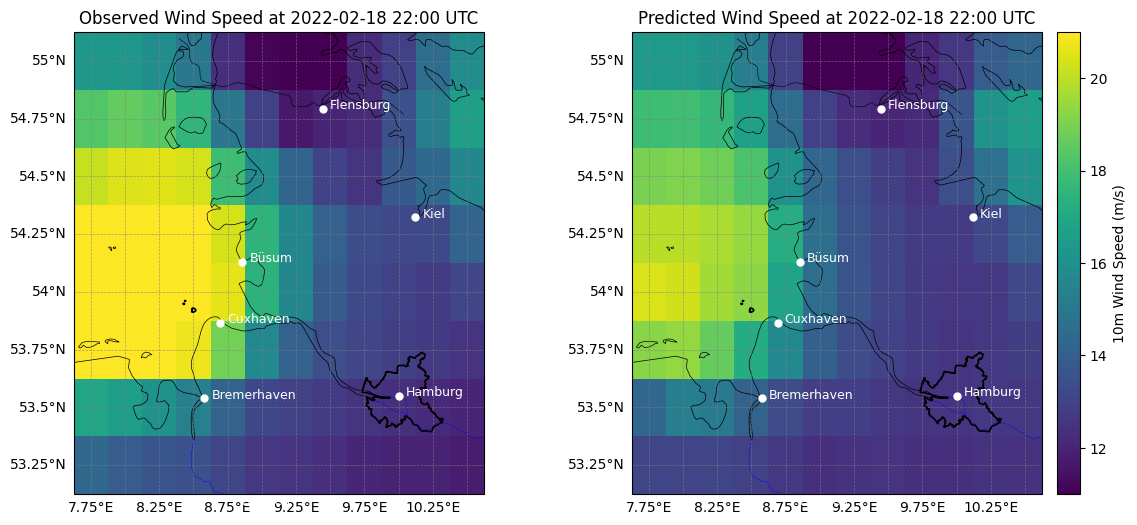

In [24]:
plot_wind_speed_comparison(
    predictions_path="data/predictions/zeynep_22_prediction_graphcast_operational.nc",
    input_path="data/input_data/zeynep_22_graphcast_operational/graphcast_ready_input_zeynep_22_graphcast_operational.nc",
    time_label="2022-02-18 22:00 UTC"
)

### Small

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_21021/4029458296.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  with xr.open_dataset(predictions_path) as ds:


📦 Using checkpoint: graphcast/params/GraphCast_operational - ERA5-HRES 1979-2021 - resolution 0.25 - pressure levels 13 - mesh 2to6 - precipitation output only.npz


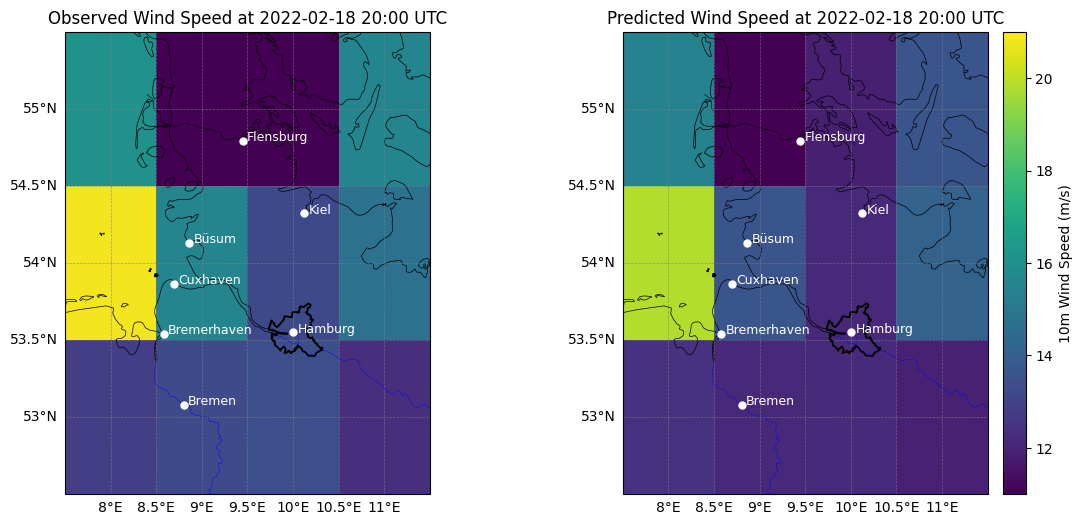

In [25]:
plot_wind_speed_comparison(
    predictions_path="data/predictions/zeynep_20_prediction_graphcast_small.nc",
    input_path="data/input_data/zeynep_20_graphcast_small/graphcast_ready_input_zeynep_20_graphcast_small.nc",
    lon_min=7.5,
    lon_max=11.5,
    lat_min=52.5,
    lat_max=55.5,
    grid_spacing=0.5,
    time_label="2022-02-18 20:00 UTC"
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_21021/4029458296.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  with xr.open_dataset(predictions_path) as ds:


📦 Using checkpoint: graphcast/params/GraphCast_operational - ERA5-HRES 1979-2021 - resolution 0.25 - pressure levels 13 - mesh 2to6 - precipitation output only.npz


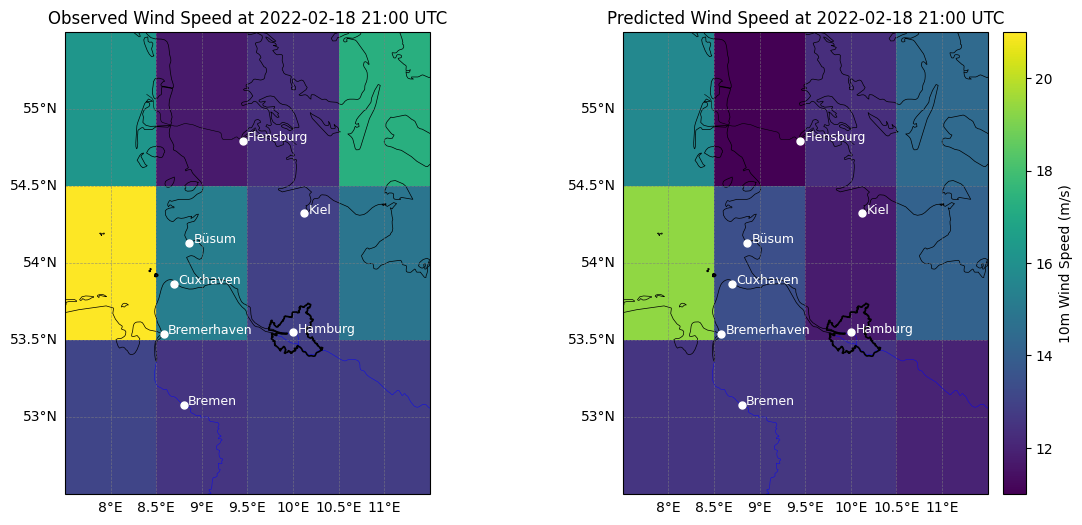

In [26]:
plot_wind_speed_comparison(
    predictions_path="data/predictions/zeynep_21_prediction_graphcast_small.nc",
    input_path="data/input_data/zeynep_21_graphcast_small/graphcast_ready_input_zeynep_21_graphcast_small.nc",
    lon_min=7.5,
    lon_max=11.5,
    lat_min=52.5,
    lat_max=55.5,
    grid_spacing=0.5,
    time_label="2022-02-18 21:00 UTC"
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_21021/4029458296.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  with xr.open_dataset(predictions_path) as ds:


📦 Using checkpoint: graphcast/params/GraphCast_operational - ERA5-HRES 1979-2021 - resolution 0.25 - pressure levels 13 - mesh 2to6 - precipitation output only.npz


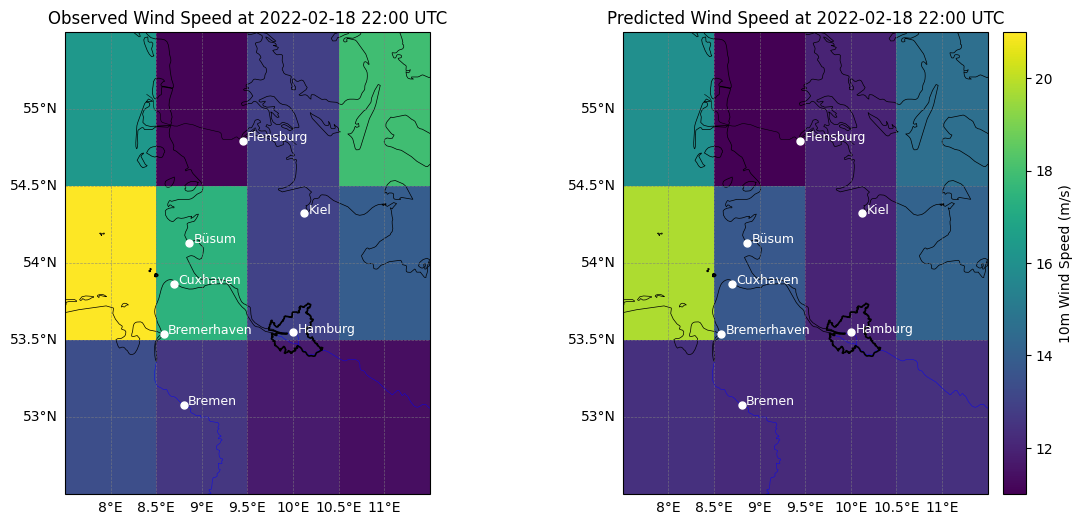

In [27]:
plot_wind_speed_comparison(
    predictions_path="data/predictions/zeynep_22_prediction_graphcast_small.nc",
    input_path="data/input_data/zeynep_22_graphcast_small/graphcast_ready_input_zeynep_22_graphcast_small.nc",
    lon_min=7.5,
    lon_max=11.5,
    lat_min=52.5,
    lat_max=55.5,
    grid_spacing=0.5,
    time_label="2022-02-18 22:00 UTC"
)